# Sanity check — diagnóstico de entrenamiento RNN/LSTM

**Propósito (exploratorio, NO va al repo):** responder antes de la campaña si las redes recurrentes salen "mal" por estar infra-entrenadas o porque es un resultado real del régimen (memoria pura, entrada sin estructura).

**Dos desenlaces, ambos útiles:**
- Con lr/profundidad/tiempo adecuados la red **mejora mucho** → estaba infra-tuneada; el grid final debe ampliar `learning_rate` (y dar tiempo).
- Aun así **se estanca por encima del reservoir** → es el resultado de tesis, y queda blindado porque se demostró que se le dio oportunidad real.

**Decisión metodológica fijada:** este diagnóstico usa **GPU** por velocidad. La **campaña final irá en CPU** para que los tiempos sean comparables entre familias (ESN numpy vs torch). Aquí NO se miden costes, solo si las redes aprenden.

Barrido: `{LSTM, simple_rnn} × lr{1e-2, 3e-3, 1e-3} × hidden{64,128} × layers{1,2}`, 1 semilla, sin tope de tiempo, `max_epochs` alto + `patience` generosa (early-stopping decide por convergencia, no por reloj). El eje `layers{1,2}` verifica el supuesto de 1 capa en vez de asumirlo.

## 1. Setup común

In [4]:
import sys
from pathlib import Path
from itertools import product

# Ajusta si el notebook no está en la raíz del repo
REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from rc_lab.runners.runner import resolve_task
from rc_lab.sequence_models.torch_models import fit_torch_sequence_model, torch_available

print("torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device usado:", DEVICE)

torch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
device usado: cuda


### Nota Blackwell (5070)
Si al entrenar en `cuda` aparece un error tipo *"no kernel image is available for execution"* o *"sm_120 not supported"*, el build de torch instalado no cubre Blackwell. Reinstalar torch con el índice CUDA adecuado. El diagnóstico funciona igual en CPU, solo más lento.

In [5]:
SEED = 42  # exploratorio: una sola semilla

# Barrido común. layers{1,2} verifica el supuesto de profundidad.
GRID = {
    "learning_rate": [1e-2, 3e-3, 1e-3],
    "hidden_size": [64, 128],
    "num_layers": [1, 2],
}
KINDS = ["torch_lstm", "torch_simple_rnn"]

# Sin tope de tiempo; early-stopping por convergencia.
BASE_CFG = {
    "max_epochs": 800,
    "patience": 50,
    "grad_clip": 1.0,
    "batch_size": 32,
    "window_stride": 50,
    "window_washout": "auto",
    "training_mode": "windowed",
    "normalize_inputs": True,
    "normalize_targets": True,
    # sin max_train_seconds_per_run -> sin tope
}

def expand(grid):
    keys = list(grid)
    return [dict(zip(keys, combo)) for combo in product(*grid.values())]

print(f"{len(KINDS) * len(expand(GRID))} runs por tarea")

24 runs por tarea


In [6]:
def run_grid_for_task(task_name, task_cfg, splits, bptt_for_task, metrics):
    """Entrena todas las combos para una tarea. Captura historial de val_loss por época.

    Devuelve (df_resumen, curves) donde curves[label] = lista de best_val_loss-by-epoch
    aproximada vía monitor (ver nota). Si el modelo no expone la curva, se usa
    best_val_loss final + epochs_ran como diagnóstico mínimo.
    """
    task = resolve_task(task_name, state_policy="reset", task_cfg=task_cfg)
    td = task.generate(**splits, seed=SEED)
    rows = []
    for kind in KINDS:
        for cp in expand(GRID):
            cfg = {**BASE_CFG, **cp, "bptt_length": bptt_for_task}
            out = fit_torch_sequence_model(
                kind=kind, task_data=td, config_point=cfg, metrics=metrics,
                seed=SEED, device=DEVICE, evaluate_test=False,
                task_name=task_name, task_cfg=task_cfg,
            )
            md = out["metadata"]
            row = {
                "kind": kind.replace("torch_", ""),
                "lr": cp["learning_rate"], "hidden": cp["hidden_size"], "layers": cp["num_layers"],
                "status": md.get("status"), "epochs": md.get("epochs_ran"),
                "best_epoch": md.get("best_epoch"), "early_stopped": md.get("early_stopped"),
                "best_val_loss": md.get("best_val_loss"),
                "n_trainable": md.get("n_trainable_params"),
            }
            row.update({f"val_{k}": v for k, v in out["val_metrics"].items()
                        if np.isscalar(v)})
            rows.append(row)
            print(f"  {row['kind']:10s} lr={row['lr']:.0e} h={row['hidden']} L={row['layers']}"
                  f"  status={row['status']:14s} epochs={row['epochs']:>3}"
                  f"  best_val={row['best_val_loss']:.4g}")
    df = pd.DataFrame(rows)
    return df, td

**Nota sobre curvas de aprendizaje.** `fit_torch_sequence_model` devuelve `best_val_loss` final y `epochs_ran`/`best_epoch`, no la traza completa por época. Para el diagnóstico, los indicadores clave son: (1) `status` — cuántos terminan `ok`/`early_stopped` vs `failed_*`; (2) `best_epoch` vs `max_epochs` — si converge pronto (sano) o usa casi todas las épocas (margen sin explotar); (3) `best_val_loss` — el nivel alcanzado. Si quieres la curva época-a-época, la celda de monitor más abajo reentrenará la mejor config registrando val_loss manualmente. Empieza por la tabla; usa el monitor solo si las curvas son necesarias.

## 2. delay_recall (kmax alto)

La tarea más sensible: si `bptt_length < kmax`, la red **no puede** aprender los retardos largos por construcción, mientras el reservoir sí los tiene en sus estados. Aquí es donde más se espera ver el límite del BPTT truncado.

In [7]:
dr_cfg = {"kmax": 100, "input_low": -1.0, "input_high": 1.0}
dr_splits = {"n_train": 3000, "n_val": 1000, "n_test": 1000, "washout": 200}
dr_metrics = ["memory_corr_total", "memory_eff_total", "nmse"]

# bptt 200 > kmax 100: la ventana cubre los retardos. Prueba luego bptt<kmax para ver el límite.
print("=== delay_recall (kmax=100, bptt=200) ===")
df_dr, td_dr = run_grid_for_task("delay_recall", dr_cfg, dr_splits, bptt_for_task=200,
                                 metrics=dr_metrics)
df_dr.sort_values("val_memory_corr_total", ascending=False).head(12)

=== delay_recall (kmax=100, bptt=200) ===
  lstm       lr=1e-02 h=64 L=1  status=ok             epochs=800  best_val=0.6043
  lstm       lr=1e-02 h=64 L=2  status=ok             epochs=500  best_val=0.6821
  lstm       lr=1e-02 h=128 L=1  status=ok             epochs=114  best_val=0.872
  lstm       lr=1e-02 h=128 L=2  status=ok             epochs=102  best_val=0.8713
  lstm       lr=3e-03 h=64 L=1  status=ok             epochs=800  best_val=0.6552
  lstm       lr=3e-03 h=64 L=2  status=ok             epochs=800  best_val=0.6123
  lstm       lr=3e-03 h=128 L=1  status=ok             epochs=191  best_val=0.8462
  lstm       lr=3e-03 h=128 L=2  status=ok             epochs=165  best_val=0.8638
  lstm       lr=1e-03 h=64 L=1  status=ok             epochs=800  best_val=0.7289
  lstm       lr=1e-03 h=64 L=2  status=ok             epochs=800  best_val=0.7118
  lstm       lr=1e-03 h=128 L=1  status=ok             epochs=566  best_val=0.761
  lstm       lr=1e-03 h=128 L=2  status=ok           

,kind,lr,hidden,layers,status,epochs,best_epoch,early_stopped,best_val_loss,n_trainable,val_memory_corr_total,val_memory_eff_total,val_nmse
19,simple_rnn,0.003,128,2,ok,800,798,False,0.229357,62692,76.505140,76.223146,0.237650
18,simple_rnn,0.003,128,1,ok,800,800,False,0.313496,29668,67.775955,67.490592,0.324807
23,simple_rnn,0.001,128,2,ok,800,800,False,0.326962,62692,66.302002,66.089855,0.338753
13,simple_rnn,0.010,64,2,ok,762,712,True,0.443145,19108,54.559706,54.026696,0.459129
22,simple_rnn,0.001,128,1,ok,800,800,False,0.445233,29668,54.196831,53.817275,0.461277
17,simple_rnn,0.003,64,2,ok,800,789,False,0.476357,19108,50.948589,50.584626,0.493532
16,simple_rnn,0.003,64,1,ok,800,800,False,0.540243,10788,44.396651,43.962864,0.559693
21,simple_rnn,0.001,64,2,ok,800,799,False,0.549653,19108,43.453854,42.974630,0.569438
15,simple_rnn,0.010,128,2,ok,264,214,True,0.606480,62692,40.858356,39.803126,0.628315
0,lstm,0.010,64,1,ok,800,779,False,0.604293,23652,37.423405,37.375815,0.625921


In [8]:
# Lectura rápida: status y si converge antes de agotar epochs
print("Distribución de status:")
print(df_dr["status"].value_counts(), "\n")
print("¿Converge pronto? best_epoch vs max_epochs=", BASE_CFG["max_epochs"])
print(df_dr.groupby(["kind"])[["best_epoch", "epochs"]].describe()[[("best_epoch","mean"),("best_epoch","max")]])

Distribución de status:
status
ok    24
Name: count, dtype: int64 

¿Converge pronto? best_epoch vs max_epochs= 800
            best_epoch       
                  mean    max
kind                         
lstm        467.500000  800.0
simple_rnn  633.833333  800.0


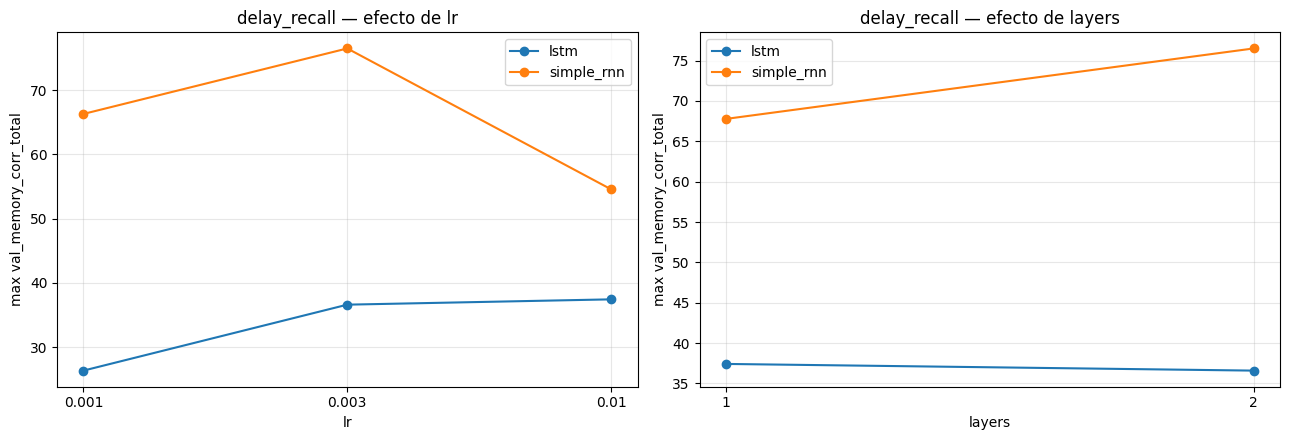

Si layers=2 no mejora sobre layers=1 -> el supuesto de 1 capa queda justificado empíricamente.


In [9]:
# Efecto del learning rate y de la profundidad (verifica el supuesto de 1 capa)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
metric = "val_memory_corr_total"
for ax, by in zip(axes, ["lr", "layers"]):
    for kind in df_dr["kind"].unique():
        sub = df_dr[df_dr["kind"] == kind]
        g = sub.groupby(by)[metric].max()  # mejor de cada nivel
        ax.plot(g.index.astype(str), g.values, marker="o", label=kind)
    ax.set_xlabel(by); ax.set_ylabel(f"max {metric}"); ax.set_title(f"delay_recall — efecto de {by}")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Si layers=2 no mejora sobre layers=1 -> el supuesto de 1 capa queda justificado empíricamente.")

### (Opcional) Monitor de curva época-a-época para la mejor config de delay_recall
Reentrena una sola config registrando val_loss manualmente, para ver la forma de la curva (¿sigue bajando al cortar? ¿plateau temprano?). Usar solo si la tabla no basta.

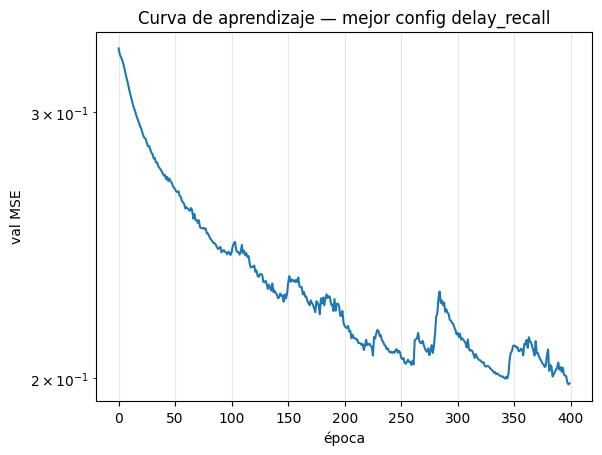

In [10]:
def monitor_curve(kind, task_data, config_point, task_name, task_cfg, seed=SEED, device=DEVICE):
    """Reentrena registrando val_loss por época. Réplica mínima del loop de entrenamiento
    para diagnóstico de curva; no sustituye a fit_torch_sequence_model."""
    import torch
    from torch import nn
    torch.manual_seed(seed)
    dev = torch.device(device)
    u_tr = torch.as_tensor(task_data.u_train, dtype=torch.float32, device=dev).unsqueeze(0)
    w = int(task_data.washout)
    y_tr = torch.as_tensor(task_data.y_train[w:], dtype=torch.float32, device=dev).unsqueeze(0)
    u_val = torch.as_tensor(task_data.u_val_full if task_data.u_val_full is not None else task_data.u_val,
                            dtype=torch.float32, device=dev).unsqueeze(0)
    y_val = torch.as_tensor(task_data.y_val, dtype=torch.float32, device=dev).unsqueeze(0)
    isz, osz = u_tr.shape[-1], y_tr.shape[-1]
    h = config_point["hidden_size"]; L = config_point["num_layers"]
    if kind == "torch_lstm":
        rec = nn.LSTM(isz, h, L, batch_first=True)
    else:
        rec = nn.RNN(isz, h, L, batch_first=True, nonlinearity="tanh")
    head = nn.Linear(h, osz)
    model = nn.Sequential()  # placeholder; usamos forward manual
    rec, head = rec.to(dev), head.to(dev)
    opt = torch.optim.Adam(list(rec.parameters()) + list(head.parameters()),
                           lr=config_point["learning_rate"])
    val_curve = []
    for ep in range(config_point.get("max_epochs", 400)):
        rec.train(); head.train(); opt.zero_grad()
        out, _ = rec(u_tr); pred = head(out)[:, w:, :]
        loss = nn.functional.mse_loss(pred, y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(rec.parameters()) + list(head.parameters()), 1.0)
        opt.step()
        rec.eval(); head.eval()
        with torch.no_grad():
            ov, _ = rec(u_val); pv = head(ov)
            if task_data.u_val_full is not None:
                pv = pv[:, w:, :]
            val_curve.append(float(nn.functional.mse_loss(pv, y_val)))
    return val_curve

# Ejemplo: descomenta para la mejor config de delay_recall
best = df_dr.sort_values('val_memory_corr_total', ascending=False).iloc[0]
cp = {'hidden_size': int(best.hidden), 'num_layers': int(best.layers),
     'learning_rate': float(best.lr), 'max_epochs': 400}
curve = monitor_curve('torch_'+best.kind, td_dr, cp, 'delay_recall', dr_cfg)
plt.plot(curve); plt.xlabel('época'); plt.ylabel('val MSE'); plt.yscale('log')
plt.title('Curva de aprendizaje — mejor config delay_recall'); plt.grid(alpha=0.3); plt.show()

## 3. narma10

Donde la literatura reporta el contraste más fuerte (ESN NRMSE ≈0.185 vs LSTM ≈0.530). **Recordatorio:** el listón de éxito real es el base case de persistencia ≈0.83 NRMSE, no 1.0. Cualquier `val_nmse` que implique NRMSE>0.83 es peor que no hacer nada.

In [11]:
n10_cfg = {}
n10_splits = {"n_train": 3000, "n_val": 1000, "n_test": 1000, "washout": 200}
n10_metrics = ["nmse", "rmse"]

print("=== narma10 (bptt=150) ===")
df_n10, td_n10 = run_grid_for_task("narma10", n10_cfg, n10_splits, bptt_for_task=150,
                                   metrics=n10_metrics)
df_n10["val_nrmse"] = np.sqrt(df_n10["val_nmse"].clip(lower=0))
df_n10.sort_values("val_nmse")

=== narma10 (bptt=150) ===
  lstm       lr=1e-02 h=64 L=1  status=ok             epochs=128  best_val=0.2224
  lstm       lr=1e-02 h=64 L=2  status=ok             epochs=135  best_val=0.2401
  lstm       lr=1e-02 h=128 L=1  status=ok             epochs=171  best_val=0.2046
  lstm       lr=1e-02 h=128 L=2  status=ok             epochs=127  best_val=0.2059
  lstm       lr=3e-03 h=64 L=1  status=ok             epochs=210  best_val=0.2052
  lstm       lr=3e-03 h=64 L=2  status=ok             epochs=459  best_val=0.1602
  lstm       lr=3e-03 h=128 L=1  status=ok             epochs=158  best_val=0.2056
  lstm       lr=3e-03 h=128 L=2  status=ok             epochs=140  best_val=0.2043
  lstm       lr=1e-03 h=64 L=1  status=ok             epochs=169  best_val=0.2598
  lstm       lr=1e-03 h=64 L=2  status=ok             epochs=488  best_val=0.1527
  lstm       lr=1e-03 h=128 L=1  status=ok             epochs=311  best_val=0.212
  lstm       lr=1e-03 h=128 L=2  status=ok             epochs=243  

,kind,lr,hidden,layers,status,epochs,best_epoch,early_stopped,best_val_loss,n_trainable,val_nmse,val_rmse,val_nrmse
22,simple_rnn,0.001,128,1,ok,508,458,True,0.049733,16897,0.035957,0.023394,0.189624
16,simple_rnn,0.003,64,1,ok,358,308,True,0.060870,4353,0.044009,0.025881,0.209784
23,simple_rnn,0.001,128,2,ok,205,155,True,0.061064,49921,0.044149,0.025922,0.210117
17,simple_rnn,0.003,64,2,ok,251,201,True,0.064430,12673,0.046583,0.026627,0.215831
21,simple_rnn,0.001,64,2,ok,255,205,True,0.070728,12673,0.051136,0.027898,0.226134
19,simple_rnn,0.003,128,2,ok,253,203,True,0.072583,49921,0.052478,0.028261,0.229080
18,simple_rnn,0.003,128,1,ok,147,97,True,0.086638,16897,0.062639,0.030877,0.250279
20,simple_rnn,0.001,64,1,ok,323,273,True,0.088909,4353,0.064282,0.031279,0.253538
14,simple_rnn,0.010,128,1,ok,297,247,True,0.101505,16897,0.073388,0.033421,0.270903
13,simple_rnn,0.010,64,2,ok,136,86,True,0.106441,12673,0.076957,0.034224,0.277411


In [12]:
print("status:", dict(df_n10["status"].value_counts()))
best_n10 = df_n10.sort_values("val_nmse").iloc[0]
print(f"\nMejor red: {best_n10.kind} lr={best_n10.lr:.0e} h={best_n10.hidden} L={best_n10.layers}")
print(f"  val_nmse={best_n10.val_nmse:.4f}  -> NRMSE={np.sqrt(max(best_n10.val_nmse,0)):.3f}")
print(f"  Persistencia (listón) NRMSE ~ 0.83. Literatura: ESN ~0.185, LSTM ~0.530")
print("  ¿La mejor red bate el listón de persistencia?", np.sqrt(max(best_n10.val_nmse,0)) < 0.83)

status: {'ok': np.int64(24)}

Mejor red: simple_rnn lr=1e-03 h=128 L=1
  val_nmse=0.0360  -> NRMSE=0.190
  Persistencia (listón) NRMSE ~ 0.83. Literatura: ESN ~0.185, LSTM ~0.530
  ¿La mejor red bate el listón de persistencia? True


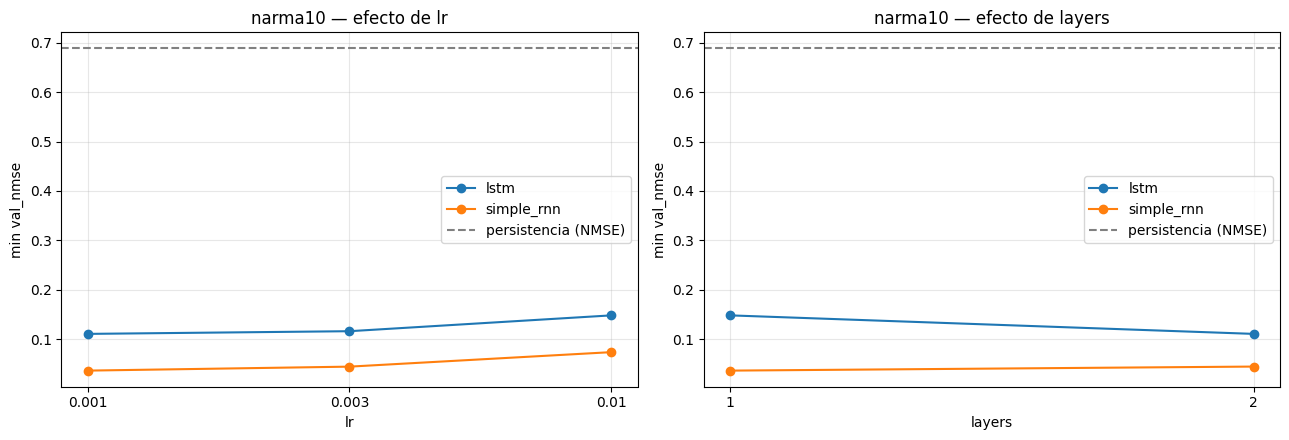

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, by in zip(axes, ["lr", "layers"]):
    for kind in df_n10["kind"].unique():
        sub = df_n10[df_n10["kind"] == kind]
        g = sub.groupby(by)["val_nmse"].min()  # menor error de cada nivel
        ax.plot(g.index.astype(str), g.values, marker="o", label=kind)
    ax.axhline(0.83**2, ls="--", c="gray", label="persistencia (NMSE)")
    ax.set_xlabel(by); ax.set_ylabel("min val_nmse"); ax.set_title(f"narma10 — efecto de {by}")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. mackey_glass (al final)

Horizonte largo (84). La persistencia es un baseline durísimo aquí, así que es informativo. Ejecutar solo si delay_recall/narma10 dejan dudas o por completitud.

In [ ]:
mg_cfg = {"tau": 17, "dt": 0.1, "beta": 0.2, "gamma": 0.1, "n": 10,
          "initial_history": "random_uniform", "history_low": 1.1, "history_high": 1.3,
          "discard_transient": 1000, "sample_stride": 10, "prediction_horizon": 84}
mg_splits = {"n_train": 3000, "n_val": 1000, "n_test": 1500, "washout": 200}
mg_metrics = ["nmse", "rmse"]

print("=== mackey_glass (horizonte 84, bptt=200) ===")
df_mg, td_mg = run_grid_for_task("mackey_glass", mg_cfg, mg_splits, bptt_for_task=200,
                                 metrics=mg_metrics)
df_mg.sort_values("val_nmse").head(12)

=== mackey_glass (horizonte 84, bptt=200) ===
  lstm       lr=1e-02 h=64 L=1  status=ok             epochs=404  best_val=0.0009945
  lstm       lr=1e-02 h=64 L=2  status=ok             epochs=462  best_val=0.000305
  lstm       lr=1e-02 h=128 L=1  status=ok             epochs=462  best_val=0.0008696
  lstm       lr=1e-02 h=128 L=2  status=ok             epochs=330  best_val=0.0007038
  lstm       lr=3e-03 h=64 L=1  status=ok             epochs=544  best_val=0.0008971
  lstm       lr=3e-03 h=64 L=2  status=ok             epochs=353  best_val=0.001298
  lstm       lr=3e-03 h=128 L=1  status=ok             epochs=377  best_val=0.00173
  lstm       lr=3e-03 h=128 L=2  status=ok             epochs=414  best_val=0.0002915
  lstm       lr=1e-03 h=64 L=1  status=ok             epochs=470  best_val=0.004593
  lstm       lr=1e-03 h=64 L=2  status=ok             epochs=414  best_val=0.00329
  lstm       lr=1e-03 h=128 L=1  status=ok             epochs=332  best_val=0.004689
  lstm       lr=1e-03 

,kind,lr,hidden,layers,status,epochs,best_epoch,early_stopped,best_val_loss,n_trainable,val_nmse,val_rmse
7,lstm,0.003,128,2,ok,414,364,True,0.000291,199297,0.000295,0.003867
1,lstm,0.010,64,2,ok,462,412,True,0.000305,50497,0.000309,0.003955
3,lstm,0.010,128,2,ok,330,280,True,0.000704,199297,0.000713,0.006008
19,simple_rnn,0.003,128,2,ok,534,484,True,0.000840,49921,0.000851,0.006565
2,lstm,0.010,128,1,ok,462,412,True,0.000870,67201,0.000881,0.006679
4,lstm,0.003,64,1,ok,544,494,True,0.000897,17217,0.000909,0.006783
0,lstm,0.010,64,1,ok,404,354,True,0.000995,17217,0.001008,0.007142
5,lstm,0.003,64,2,ok,353,303,True,0.001298,50497,0.001315,0.008160
12,simple_rnn,0.010,64,1,ok,499,449,True,0.001300,4353,0.001317,0.008166
6,lstm,0.003,128,1,ok,377,327,True,0.001730,67201,0.001753,0.009421


: 

## 5. Conclusión del diagnóstico

Rellenar tras ejecutar. Preguntas a responder:

1. **¿Status sano?** ¿La mayoría termina `early_stopped` con loss estable, o hay `failed_non_finite_loss`/runs que agotan `max_epochs` sin converger?
2. **¿lr importaba?** ¿El óptimo está en 1e-2 / 3e-3 en vez del 1e-3 fijo previo? → ampliar `learning_rate` en el grid de la campaña.
3. **¿Profundidad?** ¿layers=2 mejora algo sobre layers=1? Si no → supuesto de 1 capa justificado empíricamente para la memoria.
4. **¿Baten el listón?** ¿Las mejores redes superan la persistencia (NARMA-10 NRMSE<0.83)? Si ni con tuning generoso lo hacen de forma clara → resultado de tesis robusto.
5. **Decisión del grid final (CPU):** qué `learning_rate`, `hidden_size`, `num_layers`, `bptt_length` llevar a la campaña, y si hace falta subir `max_epochs`/`patience`.